## Install Required Libraries
This cell installs all the necessary Python packages for the project, including `langchain`, `langchain-google-genai`, `langchain-community`, `langgraph`, `python-dotenv`, `faiss-cpu`, and `pypdf`. These libraries are essential for building the RAG (Retrieval Augmented Generation) system.

In [ ]:
! pip install langchain langchain-google-genai langchain-community langgraph python-dotenv faiss-cpu pypdf

## Import Necessary Modules
This cell imports various modules and classes from the installed libraries. These imports include components for Google Generative AI, document loading and splitting, vector stores, LangGraph for orchestrating the LLM workflow, and type hints for robust code.

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

## Load Environment Variables
This cell loads environment variables from a `.env` file. This is crucial for securely managing API keys and other configuration settings without hardcoding them directly into the notebook. For example, your Google API key might be stored here.

In [6]:
# ## Load Environment Variables
# This cell loads environment variables from a `.env` file, which is crucial for securely managing API keys and other configuration settings without hardcoding them directly into the notebook.
load_dotenv()

False

## Initialize the Language Model (LLM)
This cell initializes the `ChatGoogleGenerativeAI` model, specifying the model version (`gemini-3.1-pro-preview`) and the API key. This LLM will be used for generating responses in the RAG system.

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-pro-preview",
    api_key="",
)

## Load PDF Document
This cell uses `PyPDFLoader` to load a PDF document from the specified path. The content of the PDF is then stored in the `docs` variable, which will be processed further for retrieval.

In [10]:
loader = PyPDFLoader("/content/sample_data/Software Engineer_Umar Farooq.pdf")
docs = loader.load()

## Check Document Length
This cell simply prints the number of documents loaded, confirming that the PDF was successfully processed into a list of documents.

In [11]:
len(docs)

1

## Split Documents into Chunks
This cell initializes a `RecursiveCharacterTextSplitter` to break down the loaded documents into smaller, manageable chunks. This is important for efficient retrieval, as LLMs have token limits and smaller chunks allow for more precise matching.

In [12]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

## Check Number of Chunks
This cell displays the total number of chunks created after splitting the original documents. This helps in understanding how the document content has been segmented.

In [15]:

len(chunks)

8

## Create Embeddings and Vector Store
This cell first initializes `GoogleGenerativeAIEmbeddings` with a specified embedding model (`gemini-embedding-2-preview`) and API key. It then uses FAISS (Facebook AI Similarity Search) to create a vector store from the document chunks and their generated embeddings. This vector store enables efficient similarity search for retrieval.

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2-preview",
    api_key="")
vector_store = FAISS.from_documents(chunks, embeddings)

## Display Vector Store Object
This cell simply outputs the `vector_store` object, confirming its creation and showing its memory address. It's a quick way to verify that the vector store was initialized.

In [34]:
vector_store

## Initialize Retriever
This cell converts the `vector_store` into a retriever. The retriever is configured to perform similarity searches and retrieve the top 4 most relevant document chunks based on a given query.

In [23]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

## Define RAG Tool
This cell defines a `rag_tool` function, decorated with `@tool`, making it accessible to the LLM. This tool takes a query, uses the retriever to find relevant document chunks, and returns the context and metadata, which the LLM can then use to formulate informed answers.

In [35]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

## Bind Tools to LLM
This cell creates a list of tools (in this case, just `rag_tool`) and binds them to the initialized LLM. This allows the LLM to decide when and how to use these tools to answer user queries effectively.

In [36]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

## Define Chat State
This cell defines a `TypedDict` called `ChatState` which represents the state of the conversation. It holds a list of `BaseMessage` objects, annotated with `add_messages` to manage message history within the LangGraph framework.

In [37]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

## Define Chat Node
This cell defines the `chat_node` function, which represents a node in the LangGraph. It takes the current `ChatState`, invokes the LLM (which has tools bound to it) with the current messages, and returns the LLM's response to be added to the state.

In [38]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

## Initialize Tool Node
This cell creates a `ToolNode` from the list of defined tools (`rag_tool`). In LangGraph, a `ToolNode` is responsible for executing the tools when the LLM decides they are necessary.

In [40]:
tool_node = ToolNode(tools)

## Build and Compile LangGraph Chatbot
This cell constructs the LangGraph workflow. It adds a `chat_node` and a `tools` node. It defines the flow: starting with the `chat_node`, conditionally transitioning to `tools` if the LLM decides to use them, and then returning to `chat_node` after tool execution. Finally, it compiles the graph into a runnable `chatbot`.

In [39]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

## Display Compiled Chatbot
This cell simply outputs the compiled `chatbot` object, confirming that the LangGraph has been successfully built and is ready for invocation.

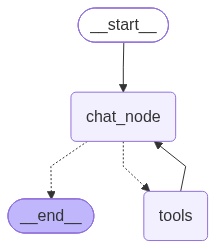

In [41]:

chatbot

## Invoke the Chatbot
This cell demonstrates how to invoke the compiled chatbot with a human message. It passes a query related to finding the ideal value of K in KNN, which the RAG system should be able to answer by retrieving information from the PDF.

In [ ]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

## Print Chatbot Result
This cell attempts to print the content of the last message from the chatbot's response. This would display the answer generated by the LLM based on the retrieved information.

In [ ]:
print(result['messages'][-1].content)